27 april 2026, making an attempt at randomforest (to predict t90) to compare to the linear model in *regression5.ipynb*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

Cell 2 — Load data

In [2]:
# Load pre-built dataset
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_clean.csv"

event_df = pd.read_csv(data_path)

print(event_df.shape)
print(event_df.head())
print(event_df.columns.tolist())

(90, 11)
                            event_id          storm  CountyFIPS         t90  \
0  2017212N28275_2017-07-30 21:00:00  2017212N28275       12075    1.885185   
1  2017242N16333_2017-09-09 19:00:00  2017242N16333       12037  120.406155   
2  2017242N16333_2017-09-09 20:00:00  2017242N16333       12067  186.802564   
3  2017242N16333_2017-09-09 21:00:00  2017242N16333       12013   52.651220   
4  2017242N16333_2017-09-09 22:00:00  2017242N16333       12075  170.764203   

   t90_censored   max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
0             0  12.601287      7.421799        67.413998      1009.864246   
1             0  27.279316     12.005697        92.750718       995.318712   
2             0  33.241034      9.333728       153.916280       982.833530   
3             0  25.291777     14.104932        89.230104       996.010565   
4             0  33.169058      9.553964       145.733609       976.919507   

   max_customers_tracked  county_pop  
0       

checks:

In [3]:
# Ensure correct types
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

# Check for missing values
print(event_df.isna().sum())

# Check target distribution
print(event_df["t90"].describe())
print("Censored fraction:", event_df["t90_censored"].mean())

event_id                 0
storm                    0
CountyFIPS               0
t90                      0
t90_censored             0
max_gust                 0
mean_gust_7d             0
total_precip_7d          0
pressure_min_7d          0
max_customers_tracked    0
county_pop               0
dtype: int64
count     90.000000
mean     143.552083
std      104.756440
min        1.885185
25%       75.481588
50%      127.678903
75%      170.772337
max      551.473029
Name: t90, dtype: float64
Censored fraction: 0.0


Cell 3 — Basic cleaning + types

In [4]:
# obsolete; use filtered dataset

Cell 4 — Build event-level dataset

In [5]:
# obsolete; use filtered dataset

Cell 5 — Merge county population

In [6]:
# obsolete; use filtered dataset

Cell 6 — Define features and target

In [7]:
feature_cols = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "max_customers_tracked",
    "county_pop",
    "CountyFIPS"
]

target_col = "t90"
group_col = "storm"

X = event_df[feature_cols].copy()
y = event_df[target_col].copy()
groups = event_df[group_col].copy()

Cell 7 — Model pipeline

In [8]:
numeric_features = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "max_customers_tracked",
    "county_pop"
]

categorical_features = ["CountyFIPS"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

Cell 8 — Random Forest model

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42
)

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", rf)
])

Cell 9 — Leave-one-storm-out CV

In [25]:
logo = LeaveOneGroupOut()

preds = np.full(len(X), np.nan)

fold_results = []

for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    storm_test = groups.iloc[test_idx].iloc[0]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    preds[test_idx] = y_pred

    fold_results.append({
        "fold": i,
        "storm": storm_test,
        "n": len(test_idx),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    })

fold_df = pd.DataFrame(fold_results)

print(fold_df)
print("\nMean MAE (per-storm avg):", fold_df["mae"].mean())
print("Global MAE:", mean_absolute_error(y, preds))
print("Mean RMSE:", fold_df["rmse"].mean())

   fold          storm   n         mae        rmse
0     1  2017212N28275   1  129.760586  129.760586
1     2  2017242N16333  49  147.560706  158.475461
2     3  2018280N18273  14  169.934392  224.951427
3     4  2020256N25281   3   31.498799   34.508631
4     5  2021182N09317   1    6.576212    6.576212
5     6  2021222N14301   3   74.119765   83.061540
6     7  2022263N10313  19   46.302368   55.033513

Mean MAE (per-storm avg): 86.53611815792476
Global MAE: 121.58326172378852
Mean RMSE: 98.90962419383051


In [26]:
print("\nWorst storms:")
print(fold_df.sort_values("mae", ascending=False).head())


Worst storms:
   fold          storm   n         mae        rmse
2     3  2018280N18273  14  169.934392  224.951427
1     2  2017242N16333  49  147.560706  158.475461
0     1  2017212N28275   1  129.760586  129.760586
5     6  2021222N14301   3   74.119765   83.061540
6     7  2022263N10313  19   46.302368   55.033513


In [11]:
# Compare performance on non-censored only
mask = event_df["t90_censored"] == 0

print("\nNon-censored only:")
print("MAE:", mean_absolute_error(y[mask], preds[mask]))
print("RMSE:", np.sqrt(mean_squared_error(y[mask], preds[mask])))


Non-censored only:
MAE: 121.58326172378852
RMSE: 150.47146089463033


if there are no censored data then why is the error different? (edit: apparently it's because it's two different aggregation methods. Mean of per-fold MAEs vs MAE over all predictions combined. it has nothing to do with censored data)

🚨 Why the numbers differed so much

Because:

large storms (many counties) had higher errors
small storms had lower errors

So:

fold average → looks optimistic (~86)
global MAE → more realistic (~121)

In [12]:
print("Total rows:", len(event_df))

# Check censored mask
mask = event_df["t90_censored"] == 0
print("Rows where t90_censored == 0:", mask.sum())

# Check if this matches what you used
print("Unique values in t90_censored:", event_df["t90_censored"].unique())

Total rows: 90
Rows where t90_censored == 0: 90
Unique values in t90_censored: [0]


Apparently it's because it's two different aggregation methods. Mean of per-fold MAEs vs MAE over all predictions combined

Cell 10 — Diagnostics

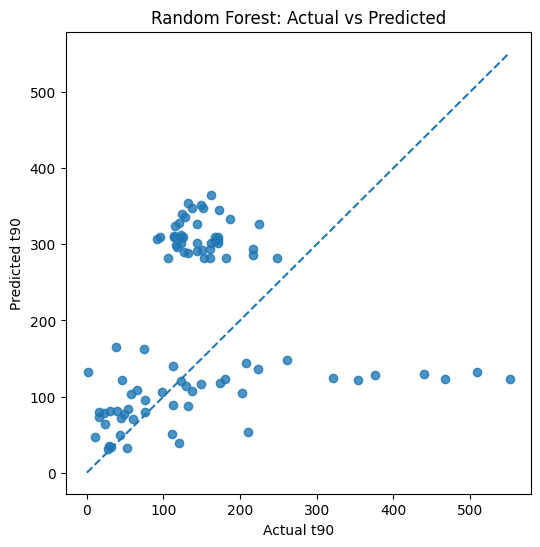

In [14]:
event_df["t90_pred"] = preds

plt.figure(figsize=(6,6))
plt.scatter(event_df["t90"], event_df["t90_pred"], alpha=0.8)
plt.plot([0, event_df["t90"].max()],
         [0, event_df["t90"].max()],
         linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Cell 11 — Feature importance

pressure_min_7d          0.363485
max_gust                 0.248599
mean_gust_7d             0.230188
total_precip_7d          0.128094
max_customers_tracked    0.017667
county_pop               0.011877
CountyFIPS_12037         0.000090
CountyFIPS_12003         0.000000
CountyFIPS_12001         0.000000
CountyFIPS_12007         0.000000
CountyFIPS_12011         0.000000
CountyFIPS_12013         0.000000
CountyFIPS_12015         0.000000
CountyFIPS_12017         0.000000
CountyFIPS_12019         0.000000
dtype: float64


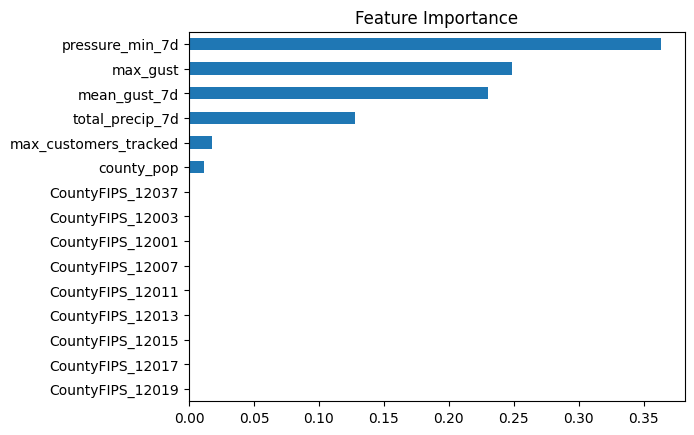

In [15]:
rf_model = model.named_steps["rf"]

# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(["CountyFIPS"])

feature_names = numeric_features + list(cat_names)

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp.head(15))

feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

Now, **without CountyFIPS**:

In [16]:
feature_cols_nocounty = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "max_customers_tracked",
    "county_pop"
]

X_nc = event_df[feature_cols_nocounty].copy()
y_nc = event_df["t90"].copy()
groups_nc = event_df["storm"].copy()

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipe_nc = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_nc = ColumnTransformer([
    ("num", numeric_pipe_nc, feature_cols_nocounty)
])

In [18]:
rf_nc = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42
)

model_nc = Pipeline([
    ("preprocess", preprocess_nc),
    ("rf", rf_nc)
])

In [19]:
logo = LeaveOneGroupOut()

preds_nc = np.full(len(X_nc), np.nan)

fold_results_nc = []

for i, (train_idx, test_idx) in enumerate(logo.split(X_nc, y_nc, groups_nc), start=1):
    X_train, X_test = X_nc.iloc[train_idx], X_nc.iloc[test_idx]
    y_train, y_test = y_nc.iloc[train_idx], y_nc.iloc[test_idx]
    storm_test = groups_nc.iloc[test_idx].iloc[0]

    model_nc.fit(X_train, y_train)
    y_pred = model_nc.predict(X_test)

    preds_nc[test_idx] = y_pred

    fold_results_nc.append({
        "fold": i,
        "storm": storm_test,
        "n": len(test_idx),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    })

fold_df_nc = pd.DataFrame(fold_results_nc)

print(fold_df_nc)
print("\nMean MAE (no county):", fold_df_nc["mae"].mean())
print("Mean RMSE (no county):", fold_df_nc["rmse"].mean())

   fold          storm   n         mae        rmse
0     1  2017212N28275   1  132.746175  132.746175
1     2  2017242N16333  49  144.880144  155.472211
2     3  2018280N18273  14  169.712923  224.518957
3     4  2020256N25281   3   31.502032   34.617144
4     5  2021182N09317   1    7.544458    7.544458
5     6  2021222N14301   3   73.418415   82.239342
6     7  2022263N10313  19   46.682767   55.493259

Mean MAE (no county): 86.64098766451436
Mean RMSE (no county): 98.94736357395585


In [20]:
print("With CountyFIPS:")
print("MAE:", fold_df["mae"].mean())
print("RMSE:", fold_df["rmse"].mean())

print("\nWithout CountyFIPS:")
print("MAE:", fold_df_nc["mae"].mean())
print("RMSE:", fold_df_nc["rmse"].mean())

With CountyFIPS:
MAE: 86.53611815792476
RMSE: 98.90962419383051

Without CountyFIPS:
MAE: 86.64098766451436
RMSE: 98.94736357395585


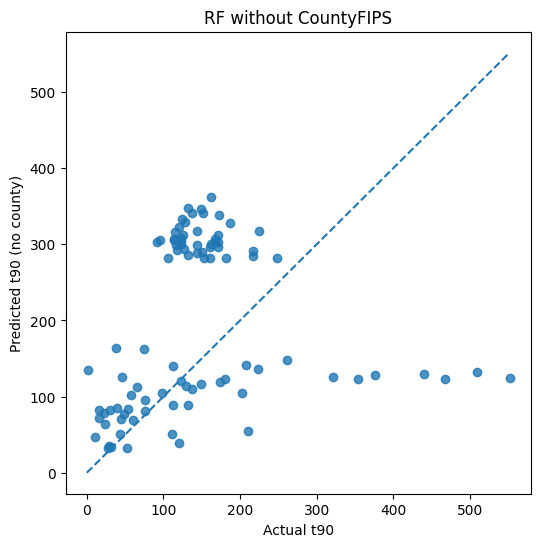

In [21]:
event_df["t90_pred_no_county"] = preds_nc

plt.figure(figsize=(6,6))
plt.scatter(event_df["t90"], event_df["t90_pred_no_county"], alpha=0.8)

m = event_df["t90"].max()
plt.plot([0, m], [0, m], linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90 (no county)")
plt.title("RF without CountyFIPS")
plt.show()

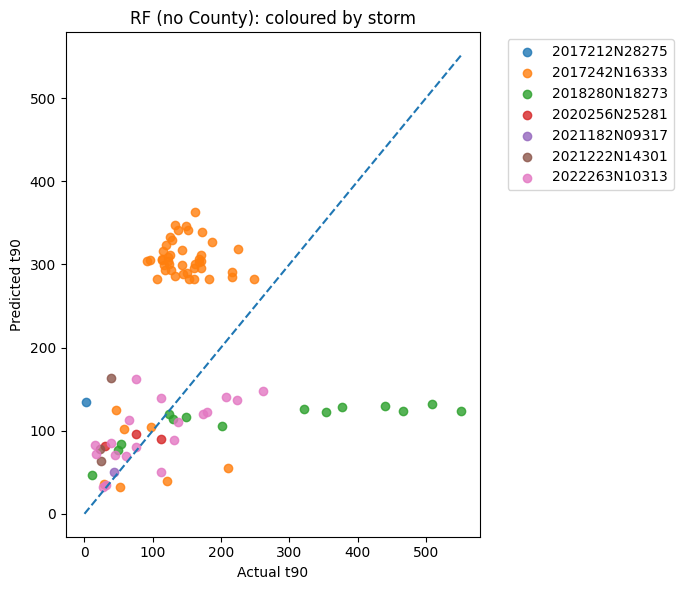

In [22]:
import matplotlib.pyplot as plt

# Ensure predictions exist
# (from your RF without county run)
# event_df["t90_pred_no_county"] should already be present

plt.figure(figsize=(7,6))

storms = event_df["storm"].unique()

for storm in storms:
    subset = event_df[event_df["storm"] == storm]
    plt.scatter(
        subset["t90"],
        subset["t90_pred_no_county"],
        label=storm,
        alpha=0.8
    )

# Diagonal line
m = event_df["t90"].max()
plt.plot([0, m], [0, m], linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("RF (no County): coloured by storm")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

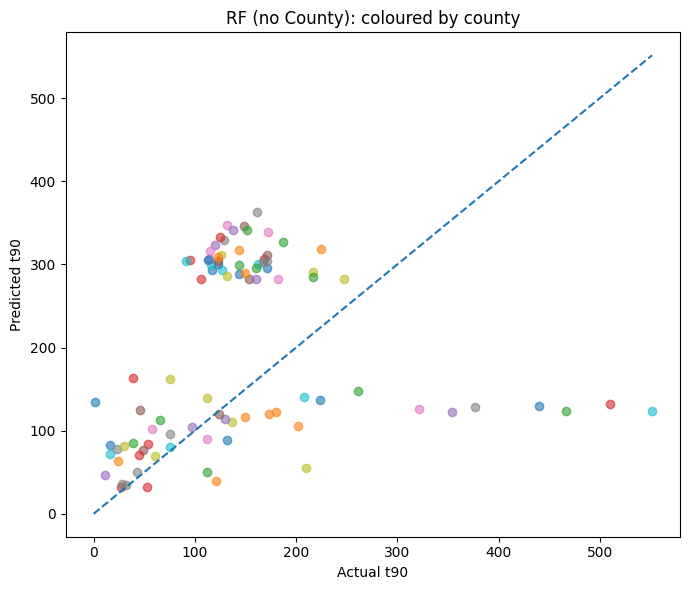

In [23]:
plt.figure(figsize=(7,6))

counties = event_df["CountyFIPS"].unique()

for county in counties:
    subset = event_df[event_df["CountyFIPS"] == county]
    plt.scatter(
        subset["t90"],
        subset["t90_pred_no_county"],
        alpha=0.6
    )

# Diagonal
m = event_df["t90"].max()
plt.plot([0, m], [0, m], linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("RF (no County): coloured by county")

plt.tight_layout()
plt.show()

^ no real trend

Trying to understand the 'censored' stuff:

Number of censored events: 0

Censored events:
Empty DataFrame
Columns: [event_id, CountyFIPS, t90]
Index: []


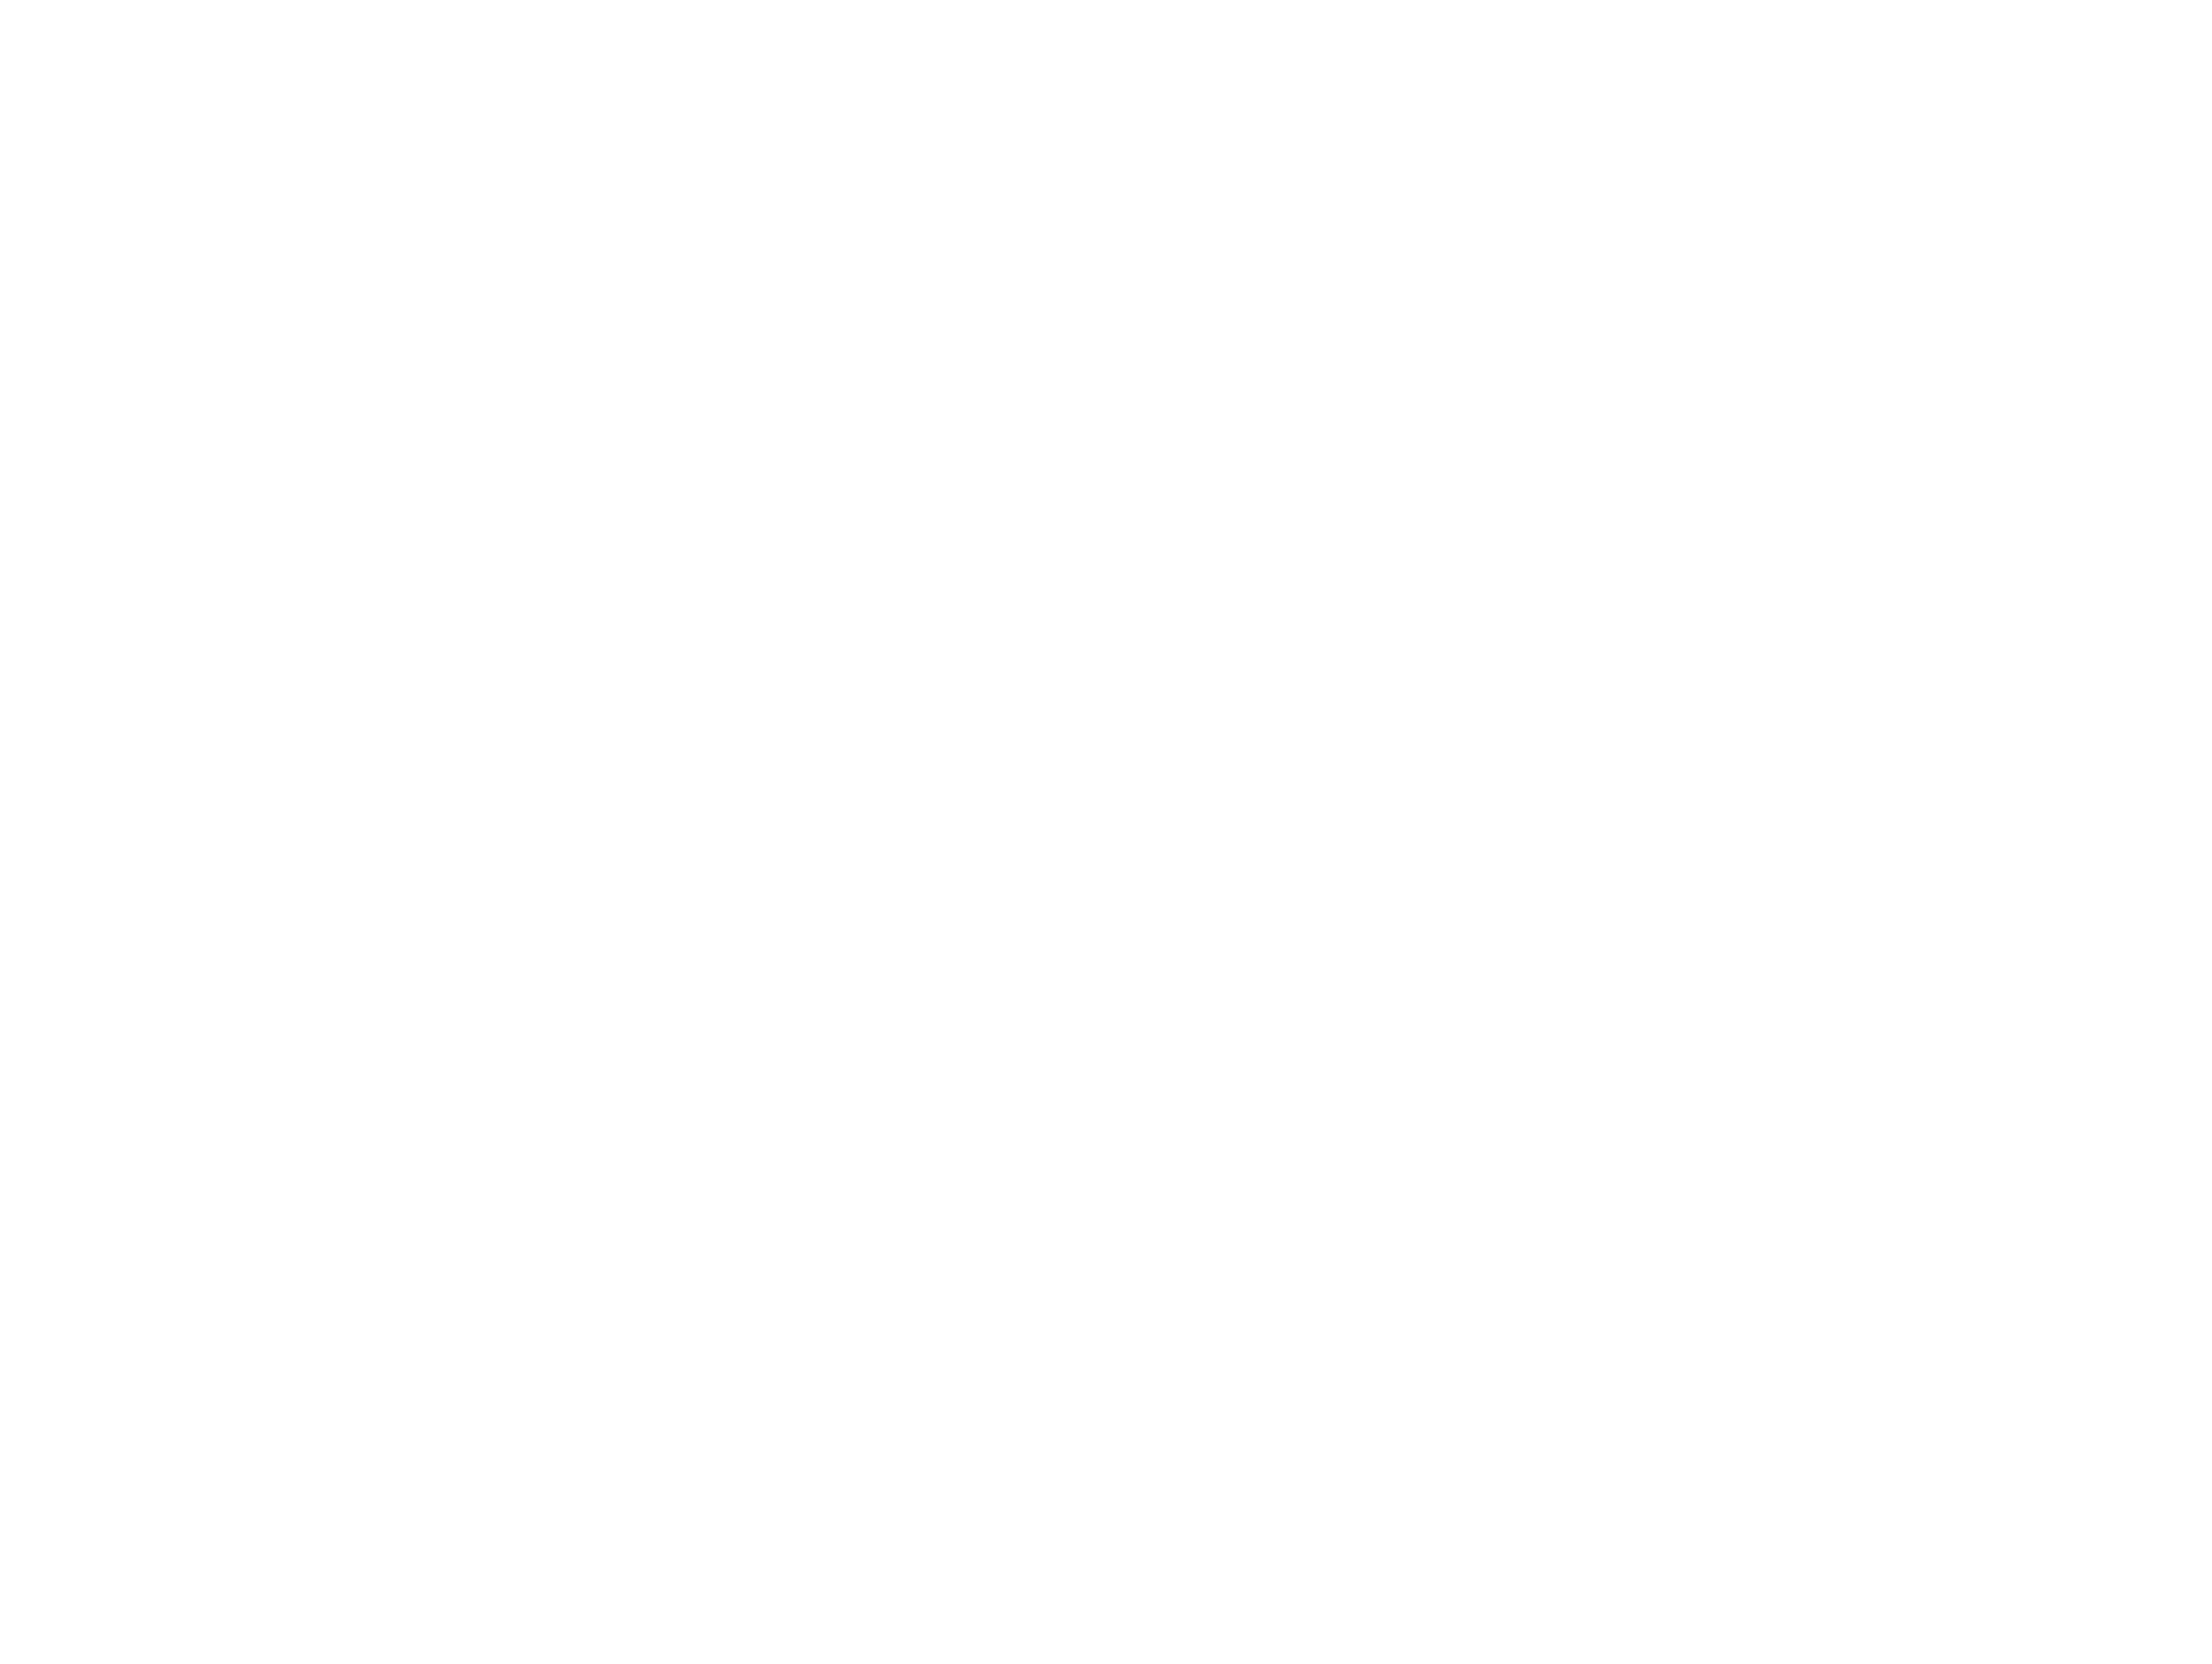

In [24]:
# -----------------------
# Identify "censored" events
# -----------------------
censored = event_df[event_df["t90_censored"] == 1].copy()

print("Number of censored events:", len(censored))
print("\nCensored events:")
print(censored[["event_id", "CountyFIPS", "t90"]].head())

# -----------------------
# Plot their time series
# -----------------------
plots_per_chunk = 20
chunk = 1  # change to view more

start = (chunk - 1) * plots_per_chunk
end = min(start + plots_per_chunk, len(censored))

subset = censored.iloc[start:end]

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, subset.iterrows()):
    event_id = row["event_id"]
    county = row["CountyFIPS"]

    g = df[
        (df["event_id"] == event_id) &
        (df["CountyFIPS"] == county)
    ].sort_values("datetime")

    ax.set_visible(True)

    # Plot raw
    ax.plot(g["datetime"], g["outageFraction"], color="blue", label="raw")

    # Plot cleaned if available
    if "outage_clean" in g.columns:
        ax.plot(g["datetime"], g["outage_clean"], color="green", label="clean")

    # Threshold line
    ax.axhline(0.1, linestyle="--", color="black")

    # Event start
    ax.axvline(g["event_start"].iloc[0], color="purple", linestyle="--")

    ax.set_title(f"{event_id} | {county} | t90={row['t90']:.1f}")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()